# Laboratorio 1: Series de Tiempo
## Análisis Exploratorio de Datos (EDA)
### Ingreso de viajeros internacionales a Guatemala (2009 - junio 2026)

**Integrantes:**
- Isabella Recinos Rodríguez - 23003
- Sofía López Ayerdi - 231929
- Nils Muralles Morales - 23727

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

DATA_PATH = "Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx"

# ---- Estilo visual (paleta categórica fija, validada para daltonismo) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
           "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e1e0d9",
    "axes.grid": True,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 100,
})

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

df = pd.read_excel(DATA_PATH, sheet_name="Datos")
notas = pd.read_excel(DATA_PATH, sheet_name="Notas", header=None)

print(f"Dimensiones del dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head()


Dimensiones del dataset: 161,036 filas x 13 columnas


,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1.0
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716.0
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4.0
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5.0
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1.0


## 0. Diccionario de datos y notas de la fuente

El archivo incluye una hoja **"Notas"** con advertencias metodológicas clave que condicionan todo el análisis posterior. Antes de explorar los datos vale la pena revisarlas, ya que explican patrones que de otra forma parecerían errores.

| Variable | Descripción |
|---|---|
| `Año` | Año de ingreso al país |
| `Mes cod` / `Mes` | Codificación y nombre del mes |
| `Vía` | Vía de entrada: Aérea, Terrestre, Marítima |
| `Frontera` | Frontera / puesto de ingreso específico |
| `País` | Hasta 2023: país de procedencia individual. Desde 2023: agrupación de mercado |
| `Región` | Clasificación usada para reportes nacionales |
| `Región dos` | Agrupa `Región` en continentes / grandes áreas |
| `Regiones OMT` | Subregión de la Organización Mundial del Turismo |
| `MCEO` | Mercado o agrupación comercial estratégica |
| `Agrupación Residencia` | Región de residencia del viajero |
| `Tipo de Viajero` | Turista, Crucerista, Excursionista, Viajero, Visitante |
| `Viajero` | Cantidad de viajeros (variable de medida) |


In [2]:
for _, row in notas.iterrows():
    titulo, texto = row[0], row[1]
    if pd.isna(titulo) or pd.isna(texto):
        continue
    print(f"• {titulo}\n  {texto}\n")


• Origen y estatus
  Ingreso de viajeros internacionales a Guatemala. USO EXCLUSIVAMENTE ACADÉMICO; no son cifras oficiales. Tres tramos de fuente: 2009-2020 respaldos históricos; 2021-2022 entrega del IGM (jul-2026) con caracterización; 2023-jun 2026 sistema depurado de conteos del INGUAT.

• Cobertura
  Enero 2009 a junio 2026: 210 meses consecutivos, sin huecos. 161,036 registros.

• Estructura
  Formato largo: una fila por combinación de mes, vía, frontera, país/agrupación y tipo de viajero, con la cantidad en 'Viajero' (medida). Categorías de tipo independientes; sin filas de total ni doble conteo.

• Tipo de Viajero
  Turista: pernocta al menos una noche. Excursionista: visita sin pernoctar (mismo día). Viajero: cruza frontera sin calificar como visitante (trabajo fronterizo, tránsito, carga, tripulación, comercio de alta frecuencia); NO se contabiliza como visitante. Cruceristas: pasajeros de crucero (solo hasta 2022; desde 2023 los cruceros se miden por fuente portuaria externa

**Puntos clave que se tendrán en cuenta durante el EDA:**

1. **Cobertura:** enero 2009 a junio 2026, 210 meses consecutivos sin huecos (161,036 filas), formato largo (una fila por combinación mes-vía-frontera-país-tipo de viajero).
2. **Cambio de granularidad en `País` (desde 2023):** antes de 2023 el país es individual; desde 2023 se reporta por agrupación de mercado (27 grupos). Los mercados principales (El Salvador, EE. UU., Honduras, México, etc.) siguen siendo comparables; los países pequeños quedan dentro de agrupaciones tipo "Resto del Mundo".
3. **Quiebre metodológico 2022→2023 en `Tipo de Viajero`:** desde 2023 se excluyen viajeros no turísticos de alta frecuencia (comercio fronterizo, tránsito) de la categoría "Viajero". Por eso esa categoría cae fuertemente y **no representa una caída real de turismo**. Para comparaciones consistentes en todo el período debe usarse **Turista + Excursionista**. Verificaremos el efecto exacto de este quiebre más adelante con los datos.
4. **Vía Marítima** pierde detalle de registro desde 2017, y además "Cruceristas" se mide desde 2023 por una fuente portuaria externa que no está en esta base.
5. **Pandemia:** colapso marcado desde marzo 2020, piso en 2020-2021, recuperación gradual desde 2022.
6. **Decimales en `Viajero`:** en varios tramos son estimaciones expandidas de encuesta, no conteos exactos, es decir, no son errores de captura.
7. **2026 solo cubre enero-junio** (año parcial, no comparable directamente con años completos).

## 1. Calidad de datos: valores faltantes, duplicados y valores atípicos (inciso e)

### 1.1 Valores faltantes

In [3]:
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(3)
resumen_nulos = pd.DataFrame({"nulos": nulos, "% del total": nulos_pct})
resumen_nulos


,nulos,% del total
Año,0,0.0
Mes cod,0,0.0
Mes,0,0.0
Vía,0,0.0
Frontera,0,0.0
País,0,0.0
Región,0,0.0
Región dos,0,0.0
Regiones OMT,0,0.0
MCEO,0,0.0


**Interpretación:** el conjunto de datos **no tiene valores nulos** en ninguna columna (`isnull().sum()` da 0 en todas). Esto es consistente con la nota de la fuente: solo se descartaron 2 filas sin agrupación (4 personas) durante el procesamiento, antes de entregarse esta base. Sin embargo, existe un problema de calidad más sutil: valores "faltantes encubiertos" bajo una categoría que no es NaN.

In [4]:
faltantes_encubiertos = df[df["Región dos"] == "0"]
print(f"Filas con 'Región dos' == '0' (faltante encubierto): {len(faltantes_encubiertos)}")
print(f"Viajeros involucrados: {faltantes_encubiertos['Viajero'].sum():.0f} de {df['Viajero'].sum():,.0f} totales "
      f"({faltantes_encubiertos['Viajero'].sum()/df['Viajero'].sum()*100:.4f}% del total)")
faltantes_encubiertos[["Año","Mes","Vía","Frontera","País","Región dos","Tipo de Viajero","Viajero"]]


Filas con 'Región dos' == '0' (faltante encubierto): 13
Viajeros involucrados: 821 de 52,287,937 totales (0.0016% del total)


,Año,Mes,Vía,Frontera,País,Región dos,Tipo de Viajero,Viajero
136757,2022,Ene,Aérea,01 La Aurora,Islas Vírgenes Americanas,0,Turista,43.0
137478,2022,Feb,Aérea,01 La Aurora,Islas Vírgenes Americanas,0,Turista,48.0
137620,2022,Feb,Terrestre,08 Pedro de Alvarado,República Democrática del Congo,0,Excursionista,1.0
137621,2022,Feb,Terrestre,08 Pedro de Alvarado,República Democrática del Congo,0,Turista,1.0
138151,2022,Mar,Aérea,01 La Aurora,Islas Vírgenes Americanas,0,Turista,53.0
139040,2022,Abr,Terrestre,09 San Cristóbal,República Democrática del Congo,0,Excursionista,11.0
140255,2022,Jun,Terrestre,09 San Cristóbal,República Democrática del Congo,0,Excursionista,11.0
140556,2022,Jul,Aérea,01 La Aurora,Islas Vírgenes Americanas,0,Turista,79.0
141198,2022,Ago,Aérea,01 La Aurora,Islas Vírgenes Americanas,0,Turista,81.0
141788,2022,Sep,Aérea,01 La Aurora,Islas Vírgenes Americanas,0,Turista,88.0


Se detectaron **13 filas** (todas de 2022, agrupación de residencia "Resto de mundo") con `Región dos == "0"` en vez de una categoría de región válida. El volumen es marginal (~0.002% del total de viajeros), por lo que la recomendación es **reclasificarlas como "Otros/Sin clasificar"** al construir series por región, sin que esto afecte materialmente los resultados.

### 1.2 Duplicados

In [5]:
dup_exactos = df.duplicated().sum()
print(f"Filas exactamente duplicadas (todas las columnas iguales): {dup_exactos}")


Filas exactamente duplicadas (todas las columnas iguales): 0


In [6]:
# Duplicados "semánticos": misma combinación de categorías (llave) repetida más de una vez
llave = ["Año", "Mes cod", "Vía", "Frontera", "País", "Tipo de Viajero"]
dup_llave = df.duplicated(subset=llave, keep=False)
print(f"Filas que comparten la misma combinación categórica (llave) con otra fila: {dup_llave.sum()}")
tam_grupos = df[dup_llave].groupby(llave).size()
print(f"Grupos de llaves repetidas: {tam_grupos.shape[0]}")
print("Distribución del tamaño de esos grupos (2 = un par, 3 = un trío):")
print(tam_grupos.value_counts().sort_index())
print()
print("Rango de años donde ocurre:", df.loc[dup_llave, "Año"].min(), "-", df.loc[dup_llave, "Año"].max())
df[dup_llave].sort_values(llave)[["Año","Mes cod","Vía","Frontera","País","Tipo de Viajero","Viajero"]].head(12)


Filas que comparten la misma combinación categórica (llave) con otra fila: 42
Grupos de llaves repetidas: 20
Distribución del tamaño de esos grupos (2 = un par, 3 = un trío):
2    18
3     2
Name: count, dtype: int64

Rango de años donde ocurre: 2020 - 2022


,Año,Mes cod,Vía,Frontera,País,Tipo de Viajero,Viajero
130128,2020,12,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,3.0
130129,2020,12,Terrestre,15 El Carmen,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,1.0
131981,2021,5,Aérea,01 La Aurora,Federación de Rusia,Turista,44.0
131982,2021,5,Aérea,01 La Aurora,Federación de Rusia,Turista,223.0
132717,2021,6,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,4.0
132718,2021,6,Terrestre,12 El Florido,Reino Unido de Gran Bretaña e Irlanda del Norte,Turista,1.0
133281,2021,7,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,7.0
133282,2021,7,Terrestre,15 El Carmen,Estados Unidos de América,Excursionista,13.0
138849,2022,4,Aérea,01 La Aurora,Colombia,Turista,2610.0
138850,2022,4,Aérea,01 La Aurora,Colombia,Turista,1051.0


**Interpretación:** no existen filas **exactamente duplicadas** (`df.duplicated().sum() == 0`). Sí se identificaron **42 filas agrupadas en 20 combinaciones repetidas** (18 grupos de 2 filas y 2 grupos de 3 filas) que comparten la misma combinación de año, mes, vía, frontera, país y tipo de viajero, pero con un valor distinto de `Viajero` cada una. Todas ocurren entre **2020 y 2022**, justo el tramo que la nota de la fuente describe como construido por **"agrupación de registros transaccionales"**. Esto indica que no son duplicados por error, sino **transacciones distintas dentro del mismo mes-categoría que no se consolidaron en una sola fila**. La implicación práctica es que al construir series de tiempo mensuales **se debe agregar (sumar) `Viajero` por la llave temporal + categórica**, en vez de asumir una fila por combinación, para no perder viajeros.

### 1.3 Valores atípicos (outliers)

In [7]:
df["Viajero"].describe()


count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

La variable `Viajero` es la cantidad de personas registradas en una combinación específica (mes, vía, frontera, país, tipo de viajero). Su distribución es **fuertemente asimétrica por diseño**: unas pocas combinaciones (p. ej. El Salvador por vía terrestre, o Estados Unidos por vía aérea) concentran volúmenes enormes, mientras que la mayoría de combinaciones país-mes son marginales. Un análisis de outliers a nivel de fila individual **no es apropiado para "limpiar" el dataset**, ya que los valores altos son observaciones legítimas de mercados grandes, no errores.

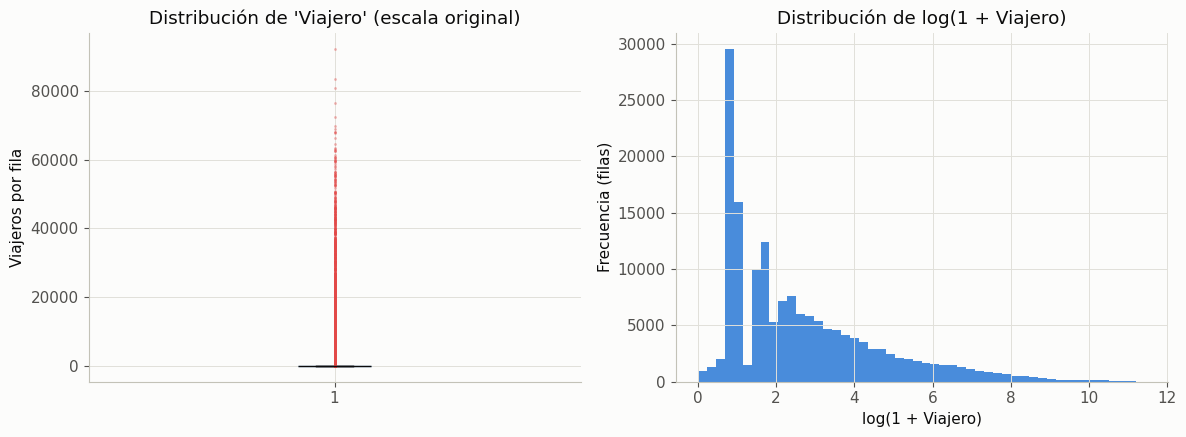

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].boxplot(df["Viajero"], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.5, edgecolor=PALETTE[0]),
                medianprops=dict(color="#0b0b0b"),
                flierprops=dict(marker="o", markersize=2, markerfacecolor=PALETTE[7], markeredgecolor="none", alpha=0.4))
axes[0].set_title("Distribución de 'Viajero' (escala original)")
axes[0].set_ylabel("Viajeros por fila")

log_vals = np.log1p(df["Viajero"])
axes[1].hist(log_vals, bins=50, color=PALETTE[0], alpha=0.85)
axes[1].set_title("Distribución de log(1 + Viajero)")
axes[1].set_xlabel("log(1 + Viajero)")
axes[1].set_ylabel("Frecuencia (filas)")

plt.tight_layout()
plt.show()


In [9]:
q1, q3 = df["Viajero"].quantile([0.25, 0.75])
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
n_outliers_iqr = (df["Viajero"] > limite_superior).sum()
print(f"Q1={q1:.1f}  Q3={q3:.1f}  IQR={iqr:.1f}  límite superior (Tukey)={limite_superior:.1f}")
print(f"Filas por encima del límite superior de Tukey: {n_outliers_iqr:,} ({n_outliers_iqr/len(df)*100:.1f}% del total)")
print()
print("Filas con Viajero == 0, por año:")
print(df.loc[df["Viajero"] == 0, "Año"].value_counts())


Q1=2.0  Q3=38.9  IQR=36.9  límite superior (Tukey)=94.2
Filas por encima del límite superior de Tukey: 26,390 (16.4% del total)

Filas con Viajero == 0, por año:
Año
2020    54
Name: count, dtype: int64


**Interpretación:**

- Con el criterio clásico de Tukey (1.5×IQR) cerca de una sexta parte de las filas calificarían como "atípicas", lo que **confirma que el criterio IQR no es útil a nivel de fila individual** en un dataset donde la escala varía por diseño según el tamaño del mercado. Los valores altos (picos de decenas de miles de viajeros en La Aurora o en fronteras con El Salvador) son reales.
- Las **54 filas con `Viajero == 0`** ocurren **exclusivamente en 2020**, el año del colapso por la pandemia y cierre de fronteras, lo cual es coherente con el contexto y no un problema de captura.
- El análisis de atípicos que sí es relevante para el laboratorio se hará **sobre las series agregadas mensuales** (con la prueba de Dickey-Fuller y gráficos de estacionalidad en la Parte 3/4), donde un "atípico" tiene sentido económico (p. ej. abril 2020).

## 2. Estadísticas descriptivas generales (inciso f)

In [10]:
print("Filas por año (deben ser ~12 meses x variedad de combinaciones; 2026 solo tiene 6 meses):")
print(df.groupby("Año").size().tail(5))
print()
print("Total de viajeros por Tipo de Viajero:")
display(df.groupby("Tipo de Viajero")["Viajero"].agg(["sum","mean","median","std","count"]).sort_values("sum", ascending=False))


Filas por año (deben ser ~12 meses x variedad de combinaciones; 2026 solo tiene 6 meses):
Año
2022    7323
2023    4660
2024    4837
2025    5148
2026    2334
dtype: int64

Total de viajeros por Tipo de Viajero:


,sum,mean,median,std,count
Tipo de Viajero,,,,,
Turista,3.764273e+07,319.244255,6.000000,2611.324160,117912
Excursionista,9.069184e+06,459.664690,10.000000,1833.670984,19730
Viajero,4.471622e+06,192.825451,8.181818,1281.234973,23190
Cruceristas,1.104402e+06,5413.735294,4454.906604,4225.763359,204


In [11]:
print("Total de viajeros por Vía:")
display(df.groupby("Vía")["Viajero"].agg(["sum","mean","median","count"]).sort_values("sum", ascending=False))


Total de viajeros por Vía:


,sum,mean,median,count
Vía,,,,
Terrestre,3.199530e+07,254.187196,7.4375,125873
Aérea,1.906385e+07,762.584511,7.0000,24999
Marítima,1.228782e+06,120.895514,3.0000,10164


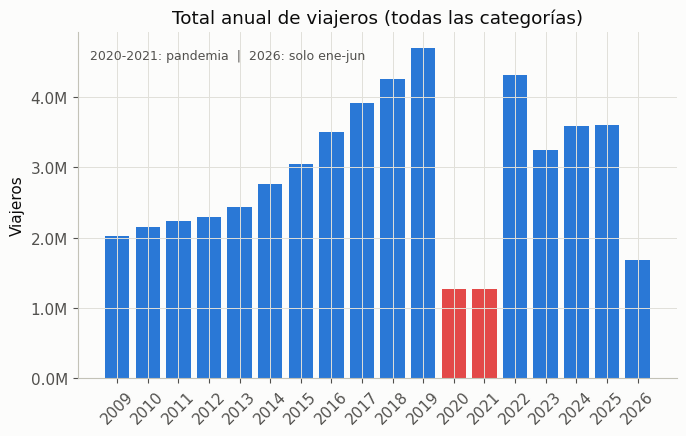

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
por_anio = df.groupby("Año")["Viajero"].sum()
colors = [PALETTE[7] if a in (2020, 2021) else PALETTE[0] for a in por_anio.index]
ax.bar(por_anio.index.astype(str), por_anio.values, color=colors)
ax.set_title("Total anual de viajeros (todas las categorías)")
ax.set_ylabel("Viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45)
ax.text(0.02, 0.95, "2020-2021: pandemia  |  2026: solo ene-jun", transform=ax.transAxes,
        fontsize=9, color="#52514e", va="top")
plt.tight_layout()
plt.show()


**Interpretación:**
- `Turista` domina el total acumulado (~37.6M de los ~52.4M viajeros-registro en todo el período), seguido de `Excursionista` (~9.1M), `Viajero` (~4.5M) y `Cruceristas` (~1.1M, discontinuado como categoría desde 2023).
- Por vía, `Terrestre` concentra la mayoría del volumen (~32.0M), seguida de `Aérea` (~19.1M) y muy por debajo `Marítima` (~1.2M), lo cual es coherente con el peso del comercio/turismo fronterizo con Centroamérica.
- El total anual muestra con claridad el **colapso de 2020-2021** (barras resaltadas) y que **2026 es un año parcial** (solo 6 de 12 meses), por lo que no debe compararse directamente contra años completos sin anualizar.

## 3. Comportamiento temporal del número de viajeros (inciso a)

Se construye la serie mensual total (todas las categorías) sumando `Viajero` por año-mes, respetando el hallazgo de la sección 1.2 (sumar, no promediar ni tomar una fila por combinación).

In [13]:
serie_total = (
    df.groupby(["Año", "Mes cod"])["Viajero"].sum()
    .reset_index()
    .assign(fecha=lambda d: pd.to_datetime(dict(year=d["Año"], month=d["Mes cod"], day=1)))
    .set_index("fecha")["Viajero"]
    .sort_index()
)
serie_total.index.freq = "MS"

print(f"Inicio: {serie_total.index.min().strftime('%Y-%m')}")
print(f"Fin: {serie_total.index.max().strftime('%Y-%m')}")
print(f"Frecuencia: mensual (MS - inicio de mes), {len(serie_total)} observaciones")
serie_total.head()


Inicio: 2009-01
Fin: 2026-06
Frecuencia: mensual (MS - inicio de mes), 210 observaciones


fecha
2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
Freq: MS, Name: Viajero, dtype: float64

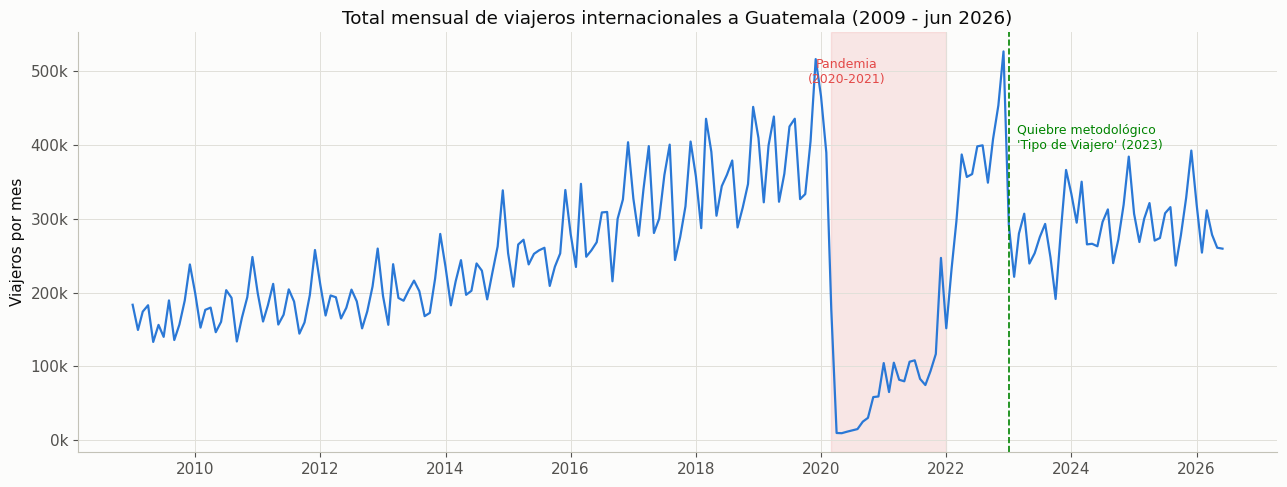

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(serie_total.index, serie_total.values, color=PALETTE[0], linewidth=1.6)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-31"), color=PALETTE[7], alpha=0.12)
ax.axvline(pd.Timestamp("2023-01-01"), color=PALETTE[5], linestyle="--", linewidth=1.2)
ax.text(pd.Timestamp("2020-06-01"), serie_total.max()*0.92, "Pandemia\n(2020-2021)",
        color=PALETTE[7], fontsize=9, ha="center")
ax.text(pd.Timestamp("2023-02-15"), serie_total.max()*0.75, "Quiebre metodológico\n'Tipo de Viajero' (2023)",
        color=PALETTE[5], fontsize=9)
ax.set_title("Total mensual de viajeros internacionales a Guatemala (2009 - jun 2026)")
ax.set_ylabel("Viajeros por mes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
plt.tight_layout()
plt.show()


**Qué se observa a primera vista:**

1. **Tendencia creciente y estable 2009-2019**: el volumen mensual crece de forma sostenida, con un patrón estacional visible (picos y valles que se repiten cada año), lo que es indicio de estacionalidad anual.
2. **Colapso abrupto en marzo de 2020**: la serie cae en pocos meses a un piso muy por debajo de su nivel histórico, y se mantiene ahí durante todo 2020 y 2021 (franja sombreada). Es el evento atípico más grande de toda la serie.
3. **Recuperación desde 2022**, con un salto que casi alcanza el nivel de 2019.
4. **Un quiebre aparente justo en enero de 2023** (línea punteada): el nivel baja de forma visible, pero como se explicó en la sección 0, esto coincide con el **cambio metodológico** en la categoría "Viajero" (excluye comercio fronterizo/tránsito desde 2023), **no necesariamente con una caída real de turismo**. Esto se verifica a continuación.

In [15]:
te = (
    df[df["Tipo de Viajero"].isin(["Turista", "Excursionista"])]
    .groupby("Año")["Viajero"].sum()
)
total_anual = df.groupby("Año")["Viajero"].sum()
viajero_cat = df[df["Tipo de Viajero"] == "Viajero"].groupby("Año")["Viajero"].sum()

comparativo = pd.DataFrame({
    "Total (todas las categorías)": total_anual,
    "Turista + Excursionista (comparable)": te,
    "Categoría 'Viajero' (rompe en 2023)": viajero_cat,
})
comparativo.loc[2019:2025].round(0)


,Total (todas las categorías),Turista + Excursionista (comparable),Categoría 'Viajero' (rompe en 2023)
Año,,,
2019,4691820.0,4132251.0,428781.0
2020,1266340.0,1059770.0,164578.0
2021,1267768.0,1098964.0,164895.0
2022,4316164.0,3229329.0,1060806.0
2023,3248709.0,2917827.0,330882.0
2024,3593876.0,3274436.0,319440.0
2025,3597238.0,3352289.0,244949.0


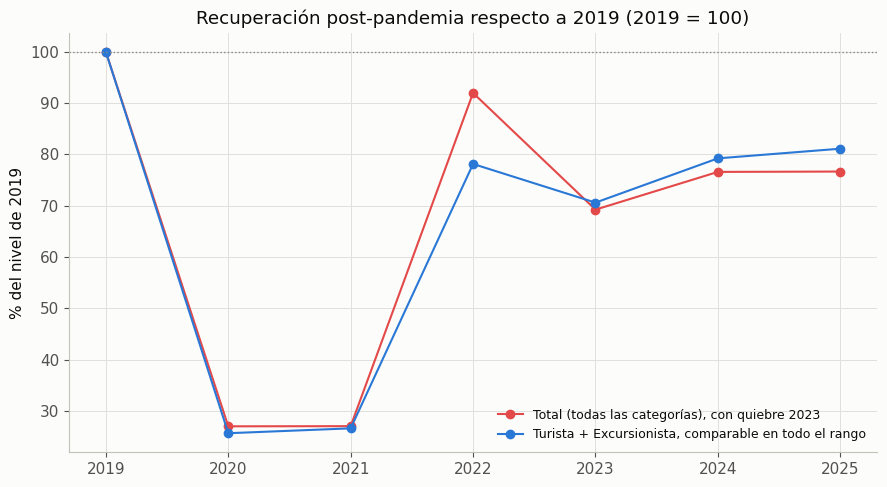

In [16]:
niv_2019_total = total_anual.loc[2019]
niv_2019_te = te.loc[2019]

fig, ax = plt.subplots(figsize=(9, 5))
years = comparativo.loc[2019:2025].index.astype(str)
ax.plot(years, comparativo.loc[2019:2025, "Total (todas las categorías)"] / niv_2019_total * 100,
        marker="o", color=PALETTE[7], label="Total (todas las categorías), con quiebre 2023")
ax.plot(years, comparativo.loc[2019:2025, "Turista + Excursionista (comparable)"] / niv_2019_te * 100,
        marker="o", color=PALETTE[0], label="Turista + Excursionista, comparable en todo el rango")
ax.axhline(100, color="#898781", linestyle=":", linewidth=1)
ax.set_title("Recuperación post-pandemia respecto a 2019 (2019 = 100)")
ax.set_ylabel("% del nivel de 2019")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


**Interpretación (comportamiento durante y después de la pandemia):**

- En **2020 y 2021** el total cae a **~27% del nivel de 2019**, un piso muy marcado y sostenido durante dos años completos, no un choque de un solo mes.
- En **2022** el total (todas las categorías) rebota hasta **~92% de 2019**, pero esa cifra está inflada por la categoría "Viajero", que ese año alcanzó ~1.06M (el nivel más alto de toda la serie para esa categoría) antes de que la metodología cambiara. Usando la medida comparable **Turista + Excursionista**, 2022 recupera solo **~78%** de 2019.
- En **2023**, el total (todas las categorías) parece caer a **~69%** de 2019. Pero gran parte de esa caída es el quiebre metodológico (la categoría "Viajero" pasa de ~1.06M a ~0.33M). La medida comparable (Turista + Excursionista) también cae ese año, a **~71%** de 2019, lo que sugiere que **sí hubo una desaceleración real adicional en 2023** (coincide con el ajuste de "sistema depurado" que también afecta el conteo de arribos marítimos, según la nota de la fuente), aunque de menor magnitud que lo que muestra el total sin ajustar.
- Para 2024 y 2025, Turista + Excursionista se recupera a **~79%** y **~81%** de 2019, respectivamente: **al último año completo de datos, el turismo medido de forma comparable todavía no vuelve al nivel prepandemia**.
- **Conclusión práctica:** cualquier análisis de tendencia/recuperación post-pandemia debe reportarse con **Turista + Excursionista**, tal como indica el enunciado, y no con el total crudo, para no confundir un cambio de definición con una caída real de demanda.

## 4. Países con mayor cantidad de viajeros (inciso b)

**Nota metodológica:** desde 2023 la columna `País` cambia de país individual a agrupación de mercado (ver sección 0). El ranking siguiente usa el **acumulado de todo el período 2009-2026**, por lo que los países grandes (que siguen siendo comparables como serie) dominan el ranking sin distorsión relevante.

In [17]:
top_paises = df.groupby("País")["Viajero"].sum().sort_values(ascending=False)
top10_paises = top_paises.head(10)
print(f"Número de países / agrupaciones distintos en la columna 'País': {df['País'].nunique()}")
top10_paises


Número de países / agrupaciones distintos en la columna 'País': 235


País
El Salvador                  1.621398e+07
Guatemala                    1.479233e+07
Estados Unidos de América    7.047843e+06
Honduras                     2.788233e+06
México                       1.808946e+06
Belice                       1.328256e+06
Nicaragua                    1.164343e+06
Cruceristas                  1.078372e+06
Costa Rica                   8.821797e+05
Colombia                     5.610353e+05
Name: Viajero, dtype: float64

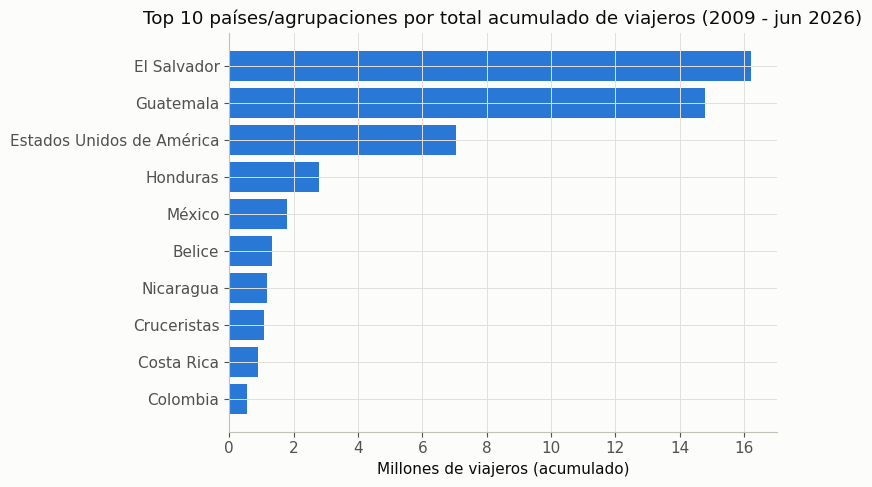

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(top10_paises.index[::-1], top10_paises.values[::-1] / 1e6, color=PALETTE[0])
ax.set_title("Top 10 países/agrupaciones por total acumulado de viajeros (2009 - jun 2026)")
ax.set_xlabel("Millones de viajeros (acumulado)")
plt.tight_layout()
plt.show()


**Interpretación:**

- Los tres países con mayor acumulado son **El Salvador (~16.2M)**, **Guatemala (~14.8M)** y **Estados Unidos (~7.0M)**, muy por encima del resto (Honduras ~2.8M, México ~1.8M).
- Que **"Guatemala" aparezca como país de origen del viajero que ingresa a Guatemala** parece contraintuitivo, pero es coherente con la naturaleza de los registros migratorios terrestres: buena parte de estos movimientos corresponden a **residentes/nacionales que cruzan la frontera terrestre de forma recurrente** (retorno de guatemaltecos, tránsito fronterizo frecuente), no a "turismo extranjero" en sentido estricto. Esto refuerza la recomendación de la fuente de usar `Tipo de Viajero` (Turista/Excursionista) para hablar específicamente de turismo.
- El dominio de **El Salvador, Guatemala y Honduras** en el top de países, junto con el peso de la vía **Terrestre** visto en la sección 2, confirma que el grueso del flujo migratorio registrado es de **naturaleza intrarregional/centroamericana** y no de turismo internacional de larga distancia.
- Estados Unidos es, por lejos, el mercado internacional (no centroamericano) más importante, seguido a distancia por México.


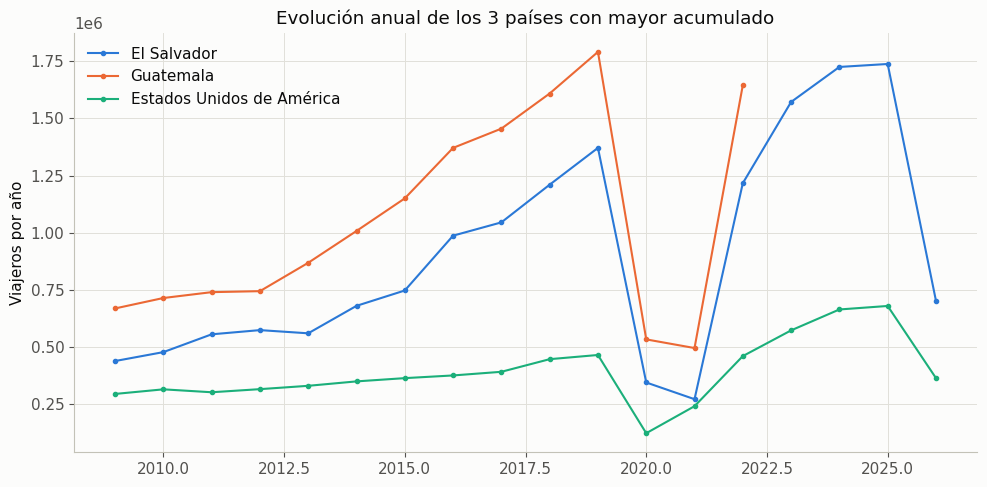

In [19]:
top3_paises = top_paises.head(3).index.tolist()
evol_top3 = (
    df[df["País"].isin(top3_paises)]
    .groupby(["Año", "País"])["Viajero"].sum()
    .unstack()
)
fig, ax = plt.subplots(figsize=(10, 5))
for i, pais in enumerate(top3_paises):
    ax.plot(evol_top3.index, evol_top3[pais], marker="o", markersize=3, color=PALETTE[i], label=pais)
ax.set_title("Evolución anual de los 3 países con mayor acumulado")
ax.set_ylabel("Viajeros por año")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Los tres países líderes comparten el mismo patrón de colapso 2020-2021 y recuperación desde 2022, pero **Estados Unidos (mercado aéreo/turístico) se recupera de forma más completa** hacia 2024-2025 que El Salvador y Guatemala (mercado terrestre/fronterizo), cuyo nivel post-pandemia parece estabilizarse algo por debajo de su pico de 2019. Esto es un primer indicio de que **la vía de ingreso condiciona la velocidad de recuperación**, algo que se profundiza en la sección 6.

## 5. Regiones con mayor cantidad de viajeros (inciso c)

Se usa `Región dos`, que agrupa la variable `Región` en continentes/grandes áreas y es la variable que el enunciado pide para la selección de las 3 regiones principales en la Parte 3.

In [20]:
top_regiones = df.groupby("Región dos")["Viajero"].sum().sort_values(ascending=False)
top_regiones


Región dos
América Del Centro             3.740653e+07
América Del Norte              9.383035e+06
Europa                         2.222621e+06
América Del Sur y el Caribe    1.447950e+06
Cruceristas                    1.078372e+06
Asia                           4.217025e+05
Oceanía                        1.400472e+05
Oriente Medio                  1.357125e+05
Cruceros                       2.603000e+04
Otros Paises Del Mundo         2.511115e+04
0                              8.210000e+02
Name: Viajero, dtype: float64

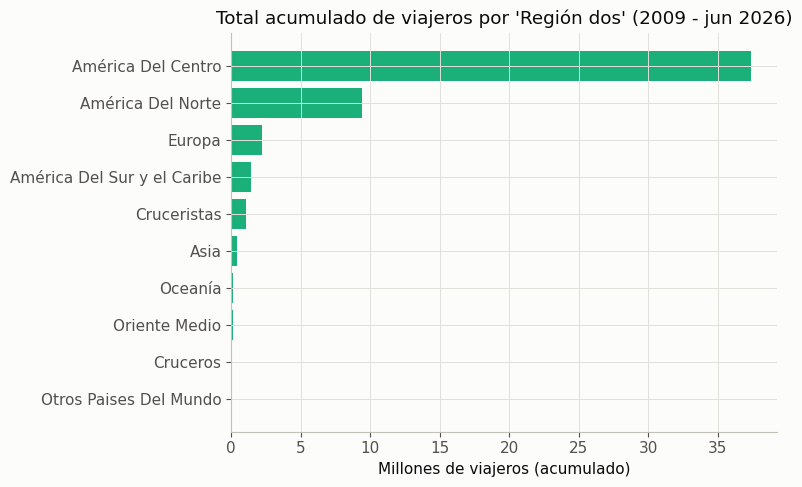

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
vals = top_regiones.drop(labels=["0"], errors="ignore")
ax.barh(vals.index[::-1], vals.values[::-1] / 1e6, color=PALETTE[2])
ax.set_title("Total acumulado de viajeros por 'Región dos' (2009 - jun 2026)")
ax.set_xlabel("Millones de viajeros (acumulado)")
plt.tight_layout()
plt.show()


**Interpretación:**

- **América del Centro (~37.4M)** domina de forma abrumadora, seguida de **América del Norte (~9.4M)** y **Europa (~2.2M)**. Estas son las **3 regiones (`Región dos`) con mayor acumulado** y las candidatas naturales para las 3 series por región que pide el Ejercicio 3.
- El resto de regiones (América del Sur y el Caribe, Asia, Oceanía, Oriente Medio) son considerablemente más pequeñas, lo que sugiere que Guatemala recibe un flujo de viajeros **muy concentrado geográficamente**: cerca del **90%** de los viajeros acumulados provienen de Centroamérica y Norteamérica combinadas.
- Categorías residuales como `"Cruceristas"`, `"Cruceros"` y `"0"` tienen participación marginal y discontinuada (Cruceristas solo hasta 2022); se excluyen del gráfico por ser ruido de clasificación, no regiones geográficas reales.

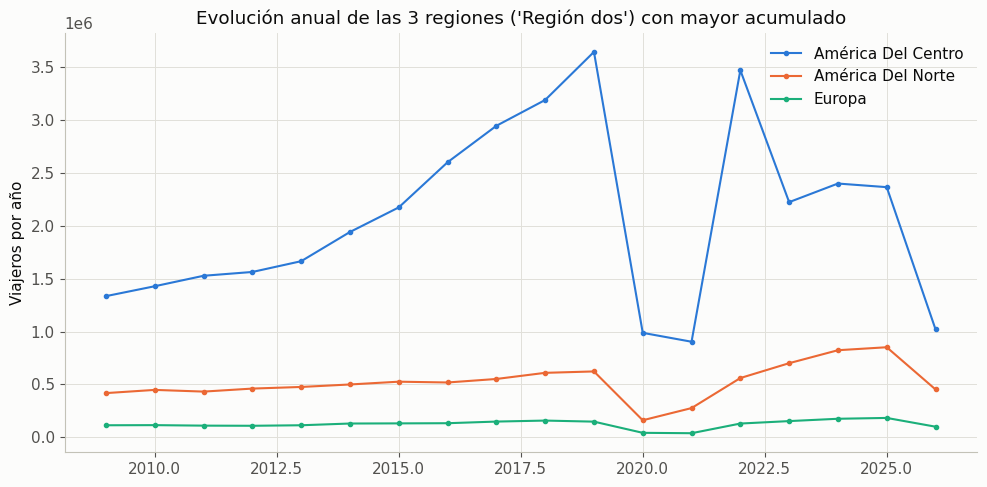

In [22]:
top3_regiones = [r for r in top_regiones.index if r not in ("0", "Cruceristas", "Cruceros")][:3]
evol_regiones = (
    df[df["Región dos"].isin(top3_regiones)]
    .groupby(["Año", "Región dos"])["Viajero"].sum()
    .unstack()
)
fig, ax = plt.subplots(figsize=(10, 5))
for i, reg in enumerate(top3_regiones):
    ax.plot(evol_regiones.index, evol_regiones[reg], marker="o", markersize=3, color=PALETTE[i], label=reg)
ax.set_title("Evolución anual de las 3 regiones ('Región dos') con mayor acumulado")
ax.set_ylabel("Viajeros por año")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Interpretación temporal:** América del Centro y América del Norte muestran el mismo patrón general (crecimiento 2009-2019, colapso 2020-2021, recuperación desde 2022), pero **Europa parece tener una caída proporcional similar en la pandemia y una recuperación más lenta**, consistente con que el turismo europeo depende de vuelos de larga distancia (más sensible a restricciones internacionales) y de un patrón estacional más marcado (vacaciones de verano/invierno boreal) que el flujo terrestre centroamericano, que es más constante mes a mes.

## 6. Vías de ingreso y fronteras más utilizadas (inciso d)

In [23]:
top_vias = df.groupby("Vía")["Viajero"].sum().sort_values(ascending=False)
top_vias_pct = (top_vias / top_vias.sum() * 100).round(1)
pd.DataFrame({"Viajeros acumulados": top_vias, "% del total": top_vias_pct})


,Viajeros acumulados,% del total
Vía,,
Terrestre,3.199530e+07,61.2
Aérea,1.906385e+07,36.5
Marítima,1.228782e+06,2.4


In [24]:
top_fronteras = df.groupby("Frontera")["Viajero"].sum().sort_values(ascending=False)
top10_fronteras = top_fronteras.head(10)
top10_fronteras


Frontera
01 La Aurora                     1.903440e+07
07 Valle Nuevo                   1.073234e+07
09 San Cristóbal                 5.363009e+06
08 Pedro de Alvarado             4.393577e+06
10 La Ermita (Nueva Anguiatú)    2.879210e+06
20 Melchor de Mencos             2.349551e+06
13 El Cinchado / El Corinto      1.497006e+06
12 El Florido                    1.221040e+06
11 Agua Caliente                 1.154542e+06
15 El Carmen                     1.023092e+06
Name: Viajero, dtype: float64

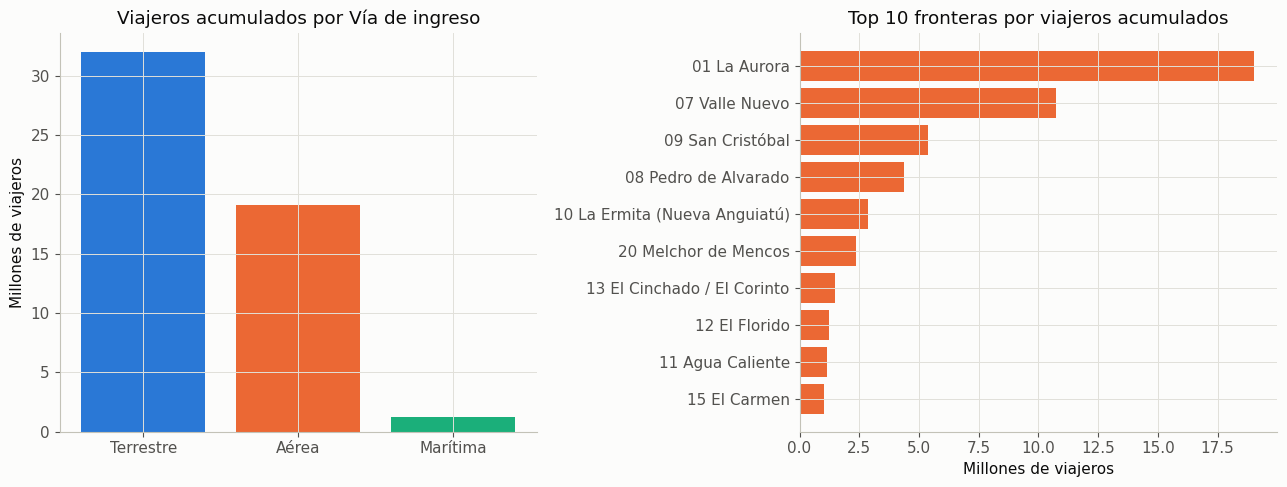

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(top_vias.index, top_vias.values / 1e6, color=PALETTE[:3])
axes[0].set_title("Viajeros acumulados por Vía de ingreso")
axes[0].set_ylabel("Millones de viajeros")

axes[1].barh(top10_fronteras.index[::-1], top10_fronteras.values[::-1] / 1e6, color=PALETTE[1])
axes[1].set_title("Top 10 fronteras por viajeros acumulados")
axes[1].set_xlabel("Millones de viajeros")

plt.tight_layout()
plt.show()


**Interpretación:**

- La vía **Terrestre concentra ~61%** del total acumulado, **Aérea ~37%** y **Marítima apenas ~2.4%** (~1.2M en términos absolutos). Esto es consistente con el peso de El Salvador/Guatemala/Honduras visto en la sección de países: la mayoría del flujo registrado cruza fronteras terrestres centroamericanas.
- Las **3 fronteras con mayor acumulado son `01 La Aurora` (~19.0M, el aeropuerto internacional, i.e. la vía aérea), `07 Valle Nuevo` (~10.7M) y `09 San Cristóbal` (~5.4M)** (estas dos últimas son cruces terrestres hacia El Salvador). Estas son las candidatas naturales para las 3 series de fronteras del Ejercicio 3.
- Nótese que el ranking de fronteras **está altamente correlacionado con el de vías y países**: La Aurora es esencialmente la serie de la vía Aérea, y Valle Nuevo/San Cristóbal reflejan el flujo con El Salvador. Elegir "Fronteras" como categoría de análisis en la Parte 3 aportaría información parcialmente redundante con "Vías" o "Países".


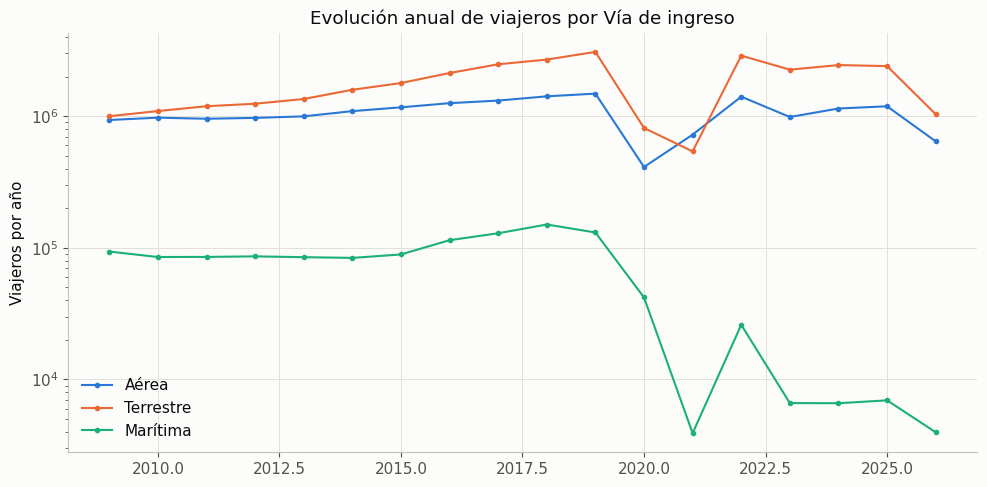

In [26]:
via_anio = df.groupby(["Año", "Vía"])["Viajero"].sum().unstack()
fig, ax = plt.subplots(figsize=(10, 5))
for i, via in enumerate(["Aérea", "Terrestre", "Marítima"]):
    ax.plot(via_anio.index, via_anio[via], marker="o", markersize=3, color=PALETTE[i], label=via)
ax.set_title("Evolución anual de viajeros por Vía de ingreso")
ax.set_ylabel("Viajeros por año")
ax.set_yscale("log")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Nota importante para la Parte 3:** la vía **Marítima** no solo es la más pequeña, sino que sufre **dos rupturas de nivel**: pierde detalle de registro desde 2017 y colapsa de forma casi permanente tras 2020 (de ~130k en 2019 a ~6-7k/año desde 2023), en parte porque desde 2023 los cruceros se miden por una fuente externa que no está en esta base. Una serie mensual de Marítima sería **discontinua y de muy difícil modelado** (ARIMA/Holt-Winters asumen un proceso razonablemente estable); esto se documenta aquí para que el grupo lo tenga en cuenta si elige "Vías de ingreso" como categoría.

## 7. Cruces de variables adicionales

Esta sección profundiza en el cruce `Tipo de Viajero` × tiempo, que es clave para entender el quiebre metodológico 2022→2023 mencionado en el enunciado, y el cruce `Vía` × `Tipo de Viajero`.

In [27]:
cruce_via_tipo = pd.crosstab(df["Vía"], df["Tipo de Viajero"], values=df["Viajero"], aggfunc="sum")
cruce_via_tipo_pct = cruce_via_tipo.div(cruce_via_tipo.sum(axis=1), axis=0) * 100
cruce_via_tipo_pct.round(1)


Tipo de Viajero,Cruceristas,Excursionista,Turista,Viajero
Vía,,,,
Aérea,NaN,0.1,99.7,0.2
Marítima,89.9,NaN,8.2,2.0
Terrestre,NaN,28.3,57.9,13.8


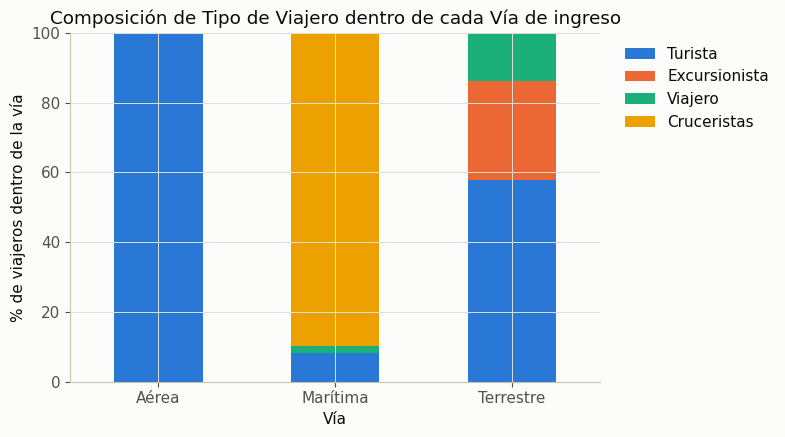

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cruce_via_tipo_pct[["Turista", "Excursionista", "Viajero", "Cruceristas"]].plot(
    kind="bar", stacked=True, ax=ax, color=PALETTE[:4]
)
ax.set_title("Composición de Tipo de Viajero dentro de cada Vía de ingreso")
ax.set_ylabel("% de viajeros dentro de la vía")
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretación:** la vía **Aérea es casi exclusivamente Turista** (~99.7%), mientras que la vía **Terrestre tiene una mezcla mucho más heterogénea** (~57.9% Turista, ~28.3% Excursionista, ~13.8% "Viajero") y la **Marítima** está dominada por "Cruceristas" (~89.9%, discontinuada desde 2023), lo cual es coherente con que la mayoría de los "Viajeros" (categoría con el quiebre metodológico) cruzan por tierra. Esto explica por qué el quiebre de 2023 afecta proporcionalmente mucho más a la serie Terrestre que a la Aérea.

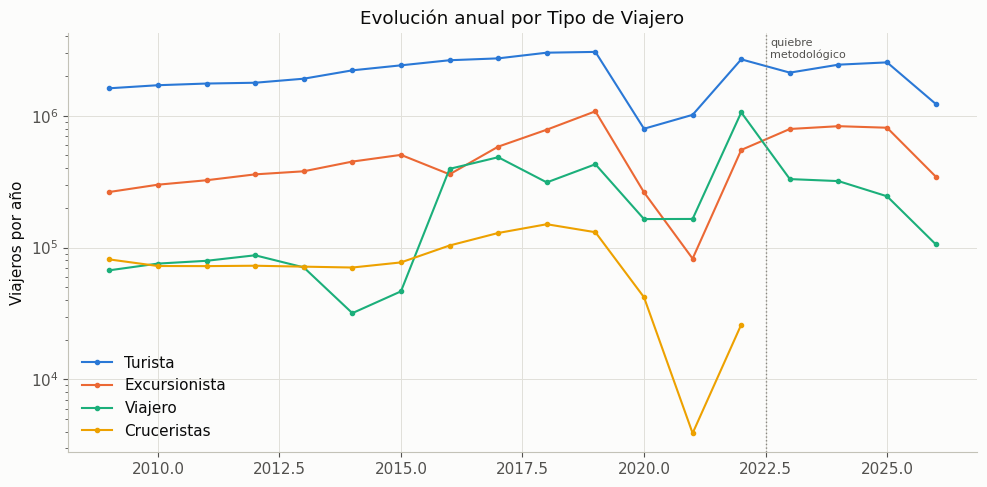

In [29]:
tipo_anio = df.groupby(["Año", "Tipo de Viajero"])["Viajero"].sum().unstack()
fig, ax = plt.subplots(figsize=(10, 5))
for i, tipo in enumerate(["Turista", "Excursionista", "Viajero", "Cruceristas"]):
    ax.plot(tipo_anio.index, tipo_anio[tipo], marker="o", markersize=3, color=PALETTE[i], label=tipo)
ax.axvline(2022.5, color="#898781", linestyle=":", linewidth=1)
ax.text(2022.6, tipo_anio.max().max()*0.9, "quiebre\nmetodológico", fontsize=8, color="#52514e")
ax.set_title("Evolución anual por Tipo de Viajero")
ax.set_ylabel("Viajeros por año")
ax.set_yscale("log")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Se confirma visualmente lo advertido en el enunciado: la categoría **"Viajero" cae de forma abrupta justo después de 2022** (de ~1.06M a ~0.33M), mientras que **Turista y Excursionista siguen una trayectoria de recuperación gradual y comparable en todo el período**. `Cruceristas` desaparece después de 2022 (medición trasladada a fuente externa). Esto confirma cuantitativamente por qué el enunciado recomienda usar Turista + Excursionista para comparar todo el rango, y por qué **la categoría "Viajero" no debería usarse tal cual para un modelo ARIMA que cubra todo 2009-2026**, sin al menos documentar/tratar el quiebre.

## 8. Estacionalidad mensual (cierre del inciso f)

Se excluyen 2020 y 2021 del promedio por mes, ya que su patrón (colapso total) no refleja la estacionalidad "normal" del turismo y distorsionaría el promedio.

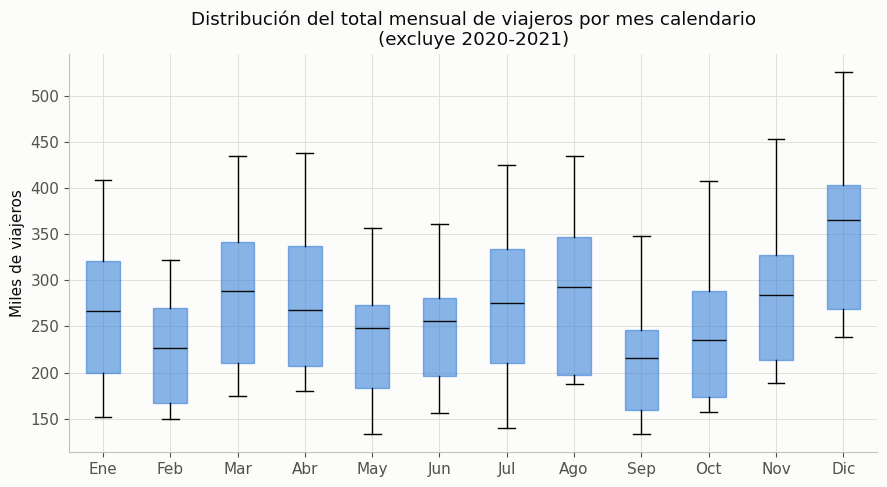

In [30]:
serie_mensual_df = serie_total.reset_index()
serie_mensual_df["anio"] = serie_mensual_df["fecha"].dt.year
serie_mensual_df["mes"] = serie_mensual_df["fecha"].dt.month
normal = serie_mensual_df[~serie_mensual_df["anio"].isin([2020, 2021])]

fig, ax = plt.subplots(figsize=(9, 5))
data_por_mes = [normal.loc[normal["mes"] == m, "Viajero"].values / 1e3 for m in range(1, 13)]
bp = ax.boxplot(data_por_mes, patch_artist=True, medianprops=dict(color="#0b0b0b"))
for patch in bp["boxes"]:
    patch.set_facecolor(PALETTE[0])
    patch.set_alpha(0.55)
    patch.set_edgecolor(PALETTE[0])
ax.set_xticklabels(["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"])
ax.set_title("Distribución del total mensual de viajeros por mes calendario\n(excluye 2020-2021)")
ax.set_ylabel("Miles de viajeros")
plt.tight_layout()
plt.show()


**Interpretación:** existe un patrón estacional claro y consistente año con año: **diciembre es, por amplio margen, el mes de mayor ingreso de viajeros** (vacaciones/fin de año), seguido de marzo-abril (Semana Santa) y julio-agosto (vacaciones de verano boreal / vacaciones escolares). Los meses de menor ingreso son **febrero y septiembre**. Esta estacionalidad anual (periodo 12) es la que se deberá modelar explícitamente en los modelos SARIMA/Holt-Winters de la Parte 4.

## 9. Principales hallazgos del análisis exploratorio

1. **Calidad de datos:** el dataset está limpio a nivel de fila (sin nulos, sin duplicados exactos); los "problemas" encontrados (13 filas con región "0", 42 filas agrupadas en 20 combinaciones categóricas repetidas, 54 filas en cero) son marginales en volumen y tienen una explicación metodológica clara documentada en la fuente, no errores de captura. La principal tarea de limpieza para la Parte 3 es **sumar correctamente por llave temporal+categórica** al construir las series mensuales.
2. **Tendencia y estacionalidad:** el volumen total creció de forma sostenida entre 2009 y 2019, con una fuerte estacionalidad anual (pico en diciembre, valle en febrero/septiembre).
3. **Pandemia:** el choque de 2020-2021 es, con diferencia, el evento más grande de toda la serie (caída a ~27% del nivel de 2019, sostenida durante 2 años completos), muy por encima de cualquier variación estacional normal.
4. **Recuperación incompleta:** usando la medida comparable Turista+Excursionista, el turismo en 2025 apenas alcanza ~81% del nivel de 2019, es decir, **la recuperación post-pandemia, al último año completo de datos, sigue incompleta**.
5. **Concentración geográfica:** ~90% de los viajeros acumulados provienen de Centroamérica y Norteamérica; El Salvador, Guatemala y Estados Unidos son, por lejos, los mercados más importantes.
6. **Concentración por vía:** la vía Terrestre (fronteras con El Salvador y Honduras principalmente) domina el volumen (~61%), seguida de Aérea (~37%); Marítima es marginal (~2.4%) y metodológicamente discontinua.
7. **Quiebre metodológico confirmado:** la categoría "Viajero" muestra una caída artificial de ~1.06M a ~0.33M entre 2022 y 2023 que **no refleja una caída real de turismo**, sino un cambio en la definición de la variable, un hallazgo crítico para no malinterpretar el "total" crudo en la Parte 4/5.